In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
df = pd.read_csv(r'C:\Kenil Ramani\QB\GoalBot\CSV\dataset_v1.27.csv')

In [66]:
df['invoiceDate'] = pd.to_datetime(df['invoiceDate'].astype(str),format="%m/%d/%Y").dt.date
df

,salesYear,salesMonth,InvoiceWeek,invoiceDate,salesDetails_id,billAmount,stockistId,chemistId,categoryId,hqId,...,free,rate,amount,productId,divisionId,product_name,packingTypeId,mrp.1,packingTypeId.1,packingTypeName
0,2021,1,1,2021-01-01,39119,457,NaN,1779.0,259.0,20.0,...,0,68.06,408.36,26,1,F-WASH SHAMPOO,38,216.0,38,100 ML
1,2021,1,1,2021-01-01,39247,45041,168.0,NaN,NaN,NaN,...,0,52.07,1562.10,168,3,BIO-ANXIT,28,85.5,28,10*10 TAB
2,2021,1,1,2021-01-01,39070,4530,NaN,5676.0,258.0,1.0,...,0,50.91,1527.30,248,3,TELEXA M 50,28,79.2,28,10*10 TAB
3,2021,1,1,2021-01-01,39436,3240,NaN,5225.0,259.0,1.0,...,0,57.86,1157.20,195,1,BIO-ITRA 100,42,180.0,42,10*10 CAP
4,2021,1,1,2021-01-01,39331,35465,93.0,NaN,NaN,17.0,...,30,40.50,0.00,254,3,VOLENT SP,28,75.6,28,10*10 TAB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129266,2025,2,6,2025-02-04,143531,129342,NaN,NaN,NaN,NaN,...,0,57.86,1157.20,172,3,BIO ANXIT NT,28,90.0,28,10*10 TAB
129267,2025,2,6,2025-02-04,143542,129342,NaN,NaN,NaN,NaN,...,0,104.14,3124.20,265,3,BIOXIGA -V,28,162.0,28,10*10 TAB
129268,2025,2,6,2025-02-04,143555,129342,NaN,NaN,NaN,NaN,...,0,48.59,2429.50,8,3,TELEXA H 40,28,69.3,28,10*10 TAB
129269,2025,2,6,2025-02-04,143513,98237,NaN,NaN,NaN,NaN,...,0,71.39,713.90,215,1,BIOKET SOAP,35,117.0,35,75 GM


In [67]:
# df = dff.drop(['salesYear', 'salesMonth', 'InvoiceWeek'],axis=1)

In [68]:
df.info()               # 120 rows have Chid & Stid,  1610 have both NaN
# df_filt = df[df['stockistId'].isnull() & df['chemistId'].isnull()]
# df_filt

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129271 entries, 0 to 129270
Data columns (total 26 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   salesYear        129271 non-null  int64  
 1   salesMonth       129271 non-null  int64  
 2   InvoiceWeek      129271 non-null  int64  
 3   invoiceDate      129271 non-null  object 
 4   salesDetails_id  129271 non-null  int64  
 5   billAmount       129271 non-null  int64  
 6   stockistId       102314 non-null  float64
 7   chemistId        25467 non-null   float64
 8   categoryId       20749 non-null   float64
 9   hqId             117350 non-null  float64
 10  hqName           117350 non-null  object 
 11  regionId         117350 non-null  float64
 12  cityId           114418 non-null  float64
 13  cityName         114418 non-null  object 
 14  mrp              129271 non-null  float64
 15  qty              129271 non-null  int64  
 16  free             129271 non-null  int6

In [ ]:
df.columns                          # 26 columns

26

In [70]:
# print(df.to_string())

In [71]:
df['productId'].unique()                 # 138

array([   26,   168,   248,   195,   254,   226,   283,    73,   218,
         234,   285,   249,    52,   233,   172,   216, 17249,   238,
           2,   223,   236,    75,   215,   205,   190,   169,   231,
         244,    70,   192,   206,     1,   212,   235,    13,   170,
           8,    35,   189,   165,   222,   181,   217,   255,   188,
         198,   252,   211,   185,   209,    27,   229,   203,   284,
         193,   220,   277,   167,   239,   241,   232,   280,    36,
         180,   221,   227,    46,   196,   253,    43,   194,   213,
          38,   173,   208,   224,   228,   177,   210,    71,   256,
         245,    42,    37, 17229,   271,   246,   261,   325,   294,
       17367,   201,   166,   260,   264,   230, 17366,   202,   263,
         278,   251,   250, 17368,   257,   265,    76,   270,   276,
          50,    48,   267,    79,   266,    11,   298,    16,    12,
          17, 17232, 17251, 17230, 17615, 17234, 17235, 17233, 17244,
       17253, 17370,

String based condition  # df.query()

In [72]:
x = df.query('chemistId.notna() and stockistId.isna()').shape[0]
x
# OR
# x = ((df['chemistId'].notna()) & (df['stockistId'].notna())).sum()
# print(x)

25347

In [73]:
# Only Graph(%)
# conditions = [
#     df['chemistId'].notna() & df['stockistId'].notna(),
#     df['chemistId'].notna() & df['stockistId'].isna(),
#     df['chemistId'].isna() & df['stockistId'].notna(),
#     df['chemistId'].isna() & df['stockistId'].isna(),
# ]

# labels = [
#     'Both Present',
#     'Only ChemistId',
#     'Only StockistId',
#     'Both Missing'
# ]

# # Count how many rows fall into each category
# counts = [condition.sum() for condition in conditions]

# # Plot pie chart
# plt.figure(figsize=(5, 5))
# plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)
# # plt.legend(title = "Data:")
# plt.title('Distribution of ChemistId and StockistId Presence')
# plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
# plt.show()

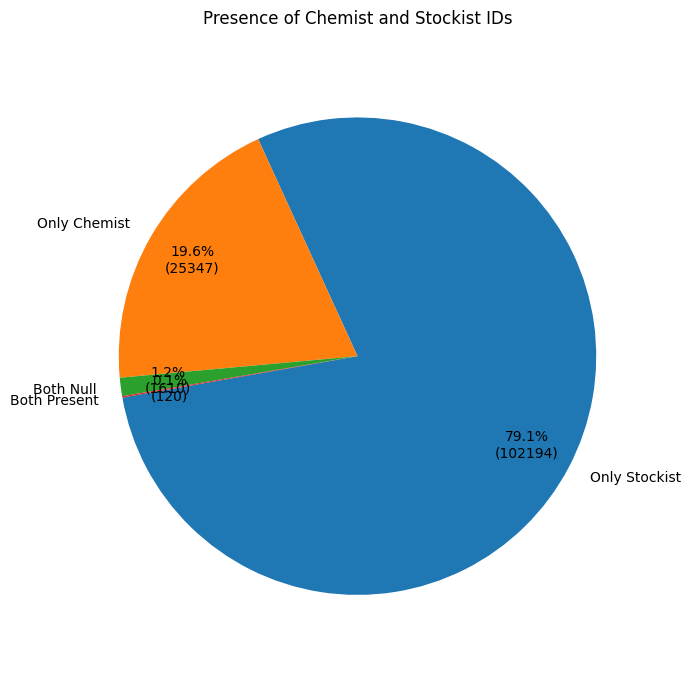

In [74]:
def classify_row(row):
    if pd.notnull(row['chemistId']) and pd.notnull(row['stockistId']):
        return 'Both Present'
    elif pd.notnull(row['chemistId']):
        return 'Only Chemist'
    elif pd.notnull(row['stockistId']):
        return 'Only Stockist'
    else:
        return 'Both Null'

df['category'] = df.apply(classify_row, axis=1)

# Count categories
category_counts = df['category'].value_counts()
labels = category_counts.index
sizes = category_counts.values

# Define labels with counts and percentages
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({count})'
    return my_autopct

# Plot
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct=make_autopct(sizes), startangle=190, labeldistance=1.1, pctdistance=0.8)
plt.title('Presence of Chemist and Stockist IDs')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(['category'], axis=1)

In [75]:
df['productId'].value_counts()              # 138

productId
168      3103
238      2903
231      2799
249      2680
239      2483
         ... 
17617      42
17624       8
17362       6
17366       3
17625       2
Name: count, Length: 138, dtype: int64

In [76]:
def sum_by_product(df):
    # df = df.dropna(subset=['productId', 'qty'])
        
    result = df.groupby(['invoiceDate', 'productId'])[['qty']].sum().reset_index()

    return result

n_df = sum_by_product(df)
print(n_df)


      invoiceDate  productId  qty
0      2021-01-01          1   50
1      2021-01-01          2   90
2      2021-01-01          8   10
3      2021-01-01         13   30
4      2021-01-01         26   56
...           ...        ...  ...
76589  2025-02-04      17244   20
76590  2025-02-04      17249   50
76591  2025-02-04      17558   78
76592  2025-02-04      17560  200
76593  2025-02-04      17616   30

[76594 rows x 3 columns]


In [77]:
n_df = n_df[n_df['productId']==26]
n_df

,invoiceDate,productId,qty
4,2021-01-01,26,56
45,2021-01-02,26,50
115,2021-01-04,26,15
169,2021-01-05,26,30
322,2021-01-08,26,10
...,...,...,...
76233,2025-01-30,26,60
76287,2025-01-31,26,20
76357,2025-02-01,26,45
76452,2025-02-03,26,50


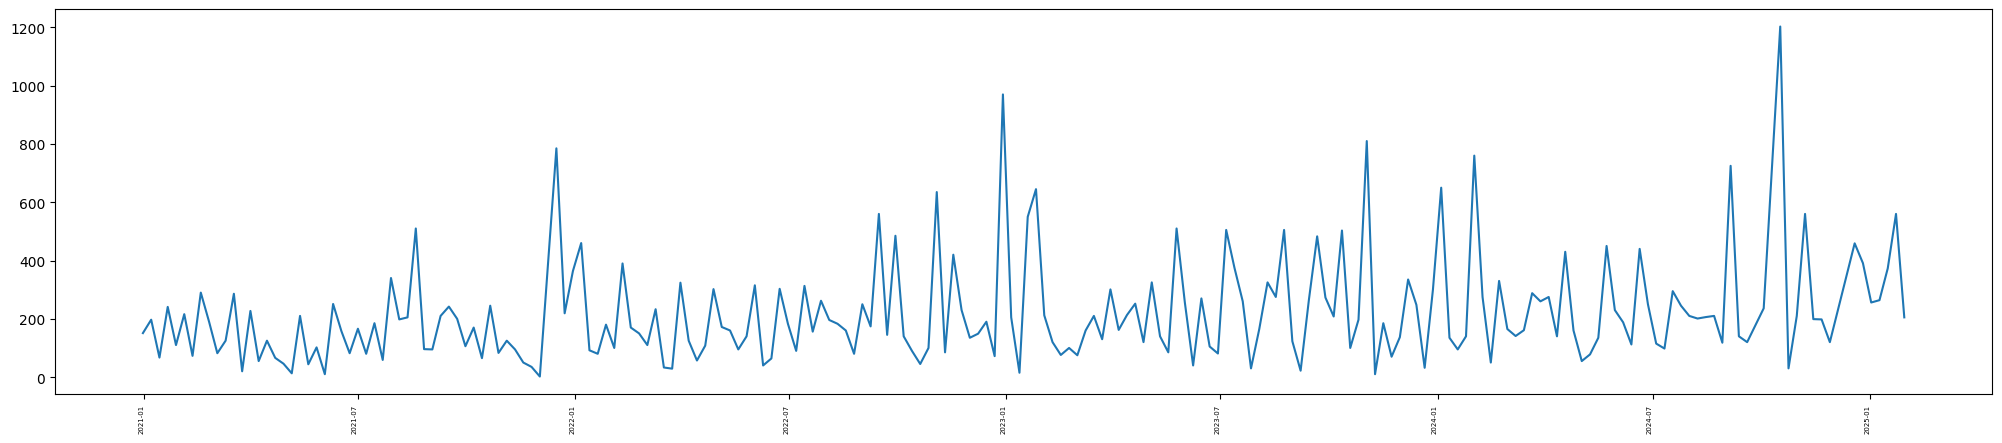

In [78]:
n_df['invoiceDate_weekstart']=n_df['invoiceDate'].values.astype('datetime64[W]')

n_df=n_df.groupby('invoiceDate_weekstart').aggregate(
    {
        'qty' : 'sum'
    }
).reset_index()

n_df.rename(columns={
        'invoiceDate_weekstart' : 'invoiceDate'
    },
    inplace=True
)

plt.figure(figsize= (25, 5))
plt.xticks(rotation= 90, ha= 'right', fontsize= 5)
plt.plot(n_df['invoiceDate'], n_df['qty'])
plt.show()

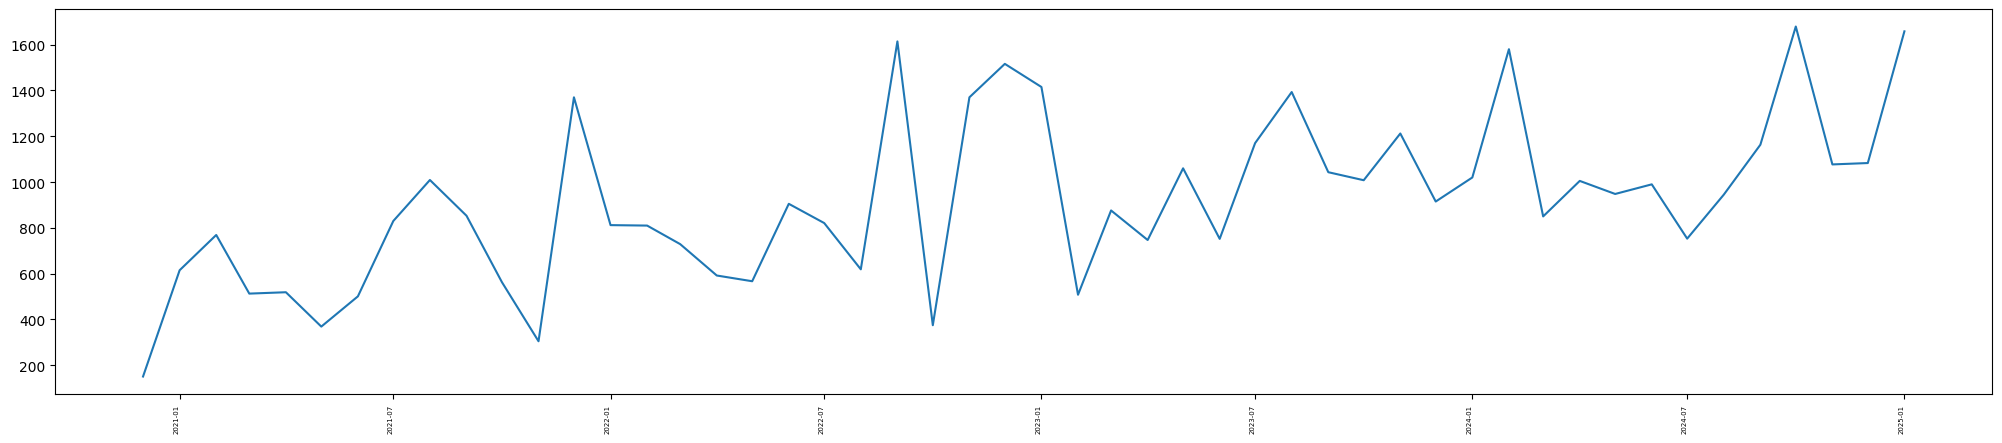

In [79]:
n_df['invoiceDate_monthstart']=n_df['invoiceDate'].values.astype('datetime64[M]')

n_df=n_df.groupby('invoiceDate_monthstart').aggregate(
    {
        'qty' : 'sum'
    }
).reset_index()

n_df.rename(columns={
        'invoiceDate_monthstart' : 'invoiceDate'
    },
    inplace=True
)


plt.figure(figsize= (25, 5))
plt.xticks(rotation= 90, ha= 'right', fontsize= 5)
plt.plot(n_df['invoiceDate'], n_df['qty'])
plt.show()

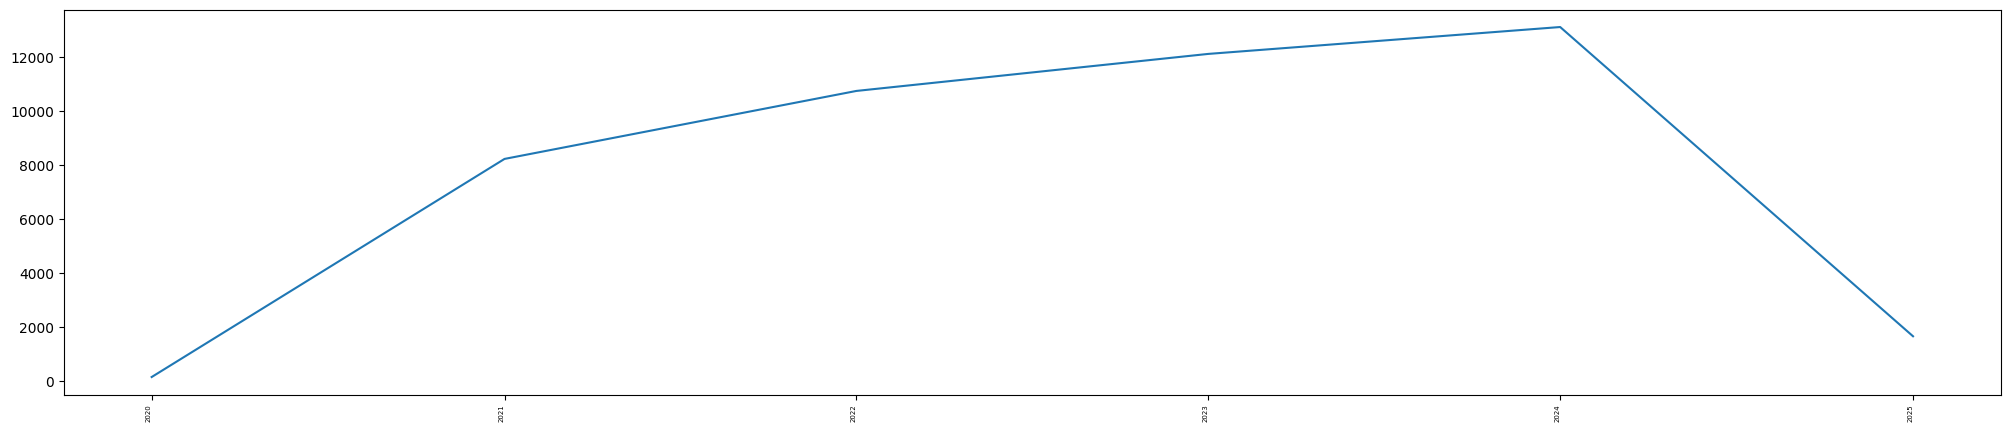

In [80]:
n_df['invoiceDate_yearstart']=n_df['invoiceDate'].values.astype('datetime64[Y]')

n_df=n_df.groupby('invoiceDate_yearstart').aggregate(
    {
        'qty' : 'sum'
    }
).reset_index()

n_df.rename(columns={
        'invoiceDate_yearstart' : 'invoiceDate'
    },
    inplace=True
)


plt.figure(figsize= (25, 5))
plt.xticks(rotation= 90, ha= 'right', fontsize= 5)
plt.plot(n_df['invoiceDate'], n_df['qty'])
plt.show()

In [81]:
class Mydf:
    def __init__(self, df):
        self.df = df

    def get_data(self):
        return self.df
    
dataframe = Mydf(df)
dataframe.get_data()


,salesYear,salesMonth,InvoiceWeek,invoiceDate,salesDetails_id,billAmount,stockistId,chemistId,categoryId,hqId,...,rate,amount,productId,divisionId,product_name,packingTypeId,mrp.1,packingTypeId.1,packingTypeName,category
0,2021,1,1,2021-01-01,39119,457,NaN,1779.0,259.0,20.0,...,68.06,408.36,26,1,F-WASH SHAMPOO,38,216.0,38,100 ML,Only Chemist
1,2021,1,1,2021-01-01,39247,45041,168.0,NaN,NaN,NaN,...,52.07,1562.10,168,3,BIO-ANXIT,28,85.5,28,10*10 TAB,Only Stockist
2,2021,1,1,2021-01-01,39070,4530,NaN,5676.0,258.0,1.0,...,50.91,1527.30,248,3,TELEXA M 50,28,79.2,28,10*10 TAB,Only Chemist
3,2021,1,1,2021-01-01,39436,3240,NaN,5225.0,259.0,1.0,...,57.86,1157.20,195,1,BIO-ITRA 100,42,180.0,42,10*10 CAP,Only Chemist
4,2021,1,1,2021-01-01,39331,35465,93.0,NaN,NaN,17.0,...,40.50,0.00,254,3,VOLENT SP,28,75.6,28,10*10 TAB,Only Stockist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129266,2025,2,6,2025-02-04,143531,129342,NaN,NaN,NaN,NaN,...,57.86,1157.20,172,3,BIO ANXIT NT,28,90.0,28,10*10 TAB,Both Null
129267,2025,2,6,2025-02-04,143542,129342,NaN,NaN,NaN,NaN,...,104.14,3124.20,265,3,BIOXIGA -V,28,162.0,28,10*10 TAB,Both Null
129268,2025,2,6,2025-02-04,143555,129342,NaN,NaN,NaN,NaN,...,48.59,2429.50,8,3,TELEXA H 40,28,69.3,28,10*10 TAB,Both Null
129269,2025,2,6,2025-02-04,143513,98237,NaN,NaN,NaN,NaN,...,71.39,713.90,215,1,BIOKET SOAP,35,117.0,35,75 GM,Both Null
